In [1]:
# =====================================================
# 0. Librerías
# =====================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from kan import *

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version usada por PyTorch:", torch.version.cuda)

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA version usada por PyTorch: 12.1


In [3]:
# =====================================================
# 2. Cargar dataset de regresión
# =====================================================

data = load_diabetes()

X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Variables:", data.feature_names)

Forma de X: (442, 10)
Forma de y: (442,)
Variables: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [4]:
# =====================================================
# 3. División train/test
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (309, 10)
X_test: (133, 10)
y_train: (309,)
y_test: (133,)


In [5]:
# =====================================================
# 4. Escalamiento
# =====================================================
# En regresión conviene escalar X y también y.
# Después regresamos las predicciones a la escala original.

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [24]:
# =====================================================
# 5. Convertir a tensores para KAN
# =====================================================
dtype = torch.get_default_dtype()
dataset = {}

dataset["train_input"] = torch.tensor(
    X_train_scaled
).type(dtype).to(device)

dataset["test_input"] = torch.tensor(
    X_test_scaled
).type(dtype).to(device)

dataset["train_label"] = torch.tensor(
    y_train_scaled
).type(dtype).to(device)

dataset["test_label"] = torch.tensor(
    y_test_scaled
).type(dtype).to(device)

print("train_input:", dataset["train_input"].shape)
print("train_label:", dataset["train_label"].shape)
print("test_input:", dataset["test_input"].shape)
print("test_label:", dataset["test_label"].shape)

train_input: torch.Size([309, 10])
train_label: torch.Size([309, 1])
test_input: torch.Size([133, 10])
test_label: torch.Size([133, 1])


In [115]:
# =====================================================
# 7. Crear modelo KAN
# =====================================================
# width = [n_entradas, neuronas_ocultas, salida]
# Como diabetes tiene 10 variables:
# width = [10, 5, 1]

import os
os.makedirs("./checkpoints_diabetes", exist_ok=True)

model = KAN(
    width=[X_train.shape[1], 2, 1],
    grid=3,
    k=3,
    seed=42,
    device=device,
    ckpt_path="./checkpoints_diabetes"
)


checkpoint directory created: ./checkpoints_diabetes
saving model version 0.0


In [104]:
# =====================================================
# 6. Definir métricas para KAN
# =====================================================

def train_mse():
    pred = model(dataset["train_input"])
    return torch.mean((pred - dataset["train_label"]) ** 2)

def test_mse():
    pred = model(dataset["test_input"])
    return torch.mean((pred - dataset["test_label"]) ** 2)

In [116]:
# =====================================================
# 8. Entrenar modelo
# =====================================================

results = model.fit(
    dataset,
    opt="Adam",
    steps=500,
    lr=0.001,
    metrics=(train_mse, test_mse),
    loss_fn=torch.nn.MSELoss(),
    lamb=0.01
)

| train_loss: 6.73e-01 | test_loss: 6.50e-01 | reg: 8.15e+00 | : 100%|█| 500/500 [00:34<00:00, 14.36


saving model version 0.1


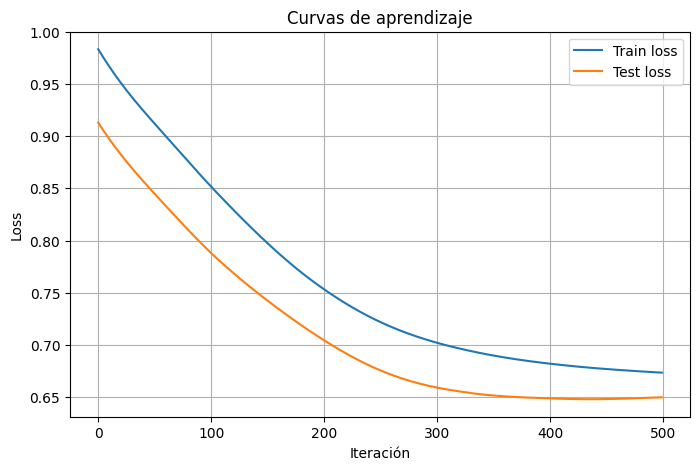

In [117]:
plt.figure(figsize=(8, 5))
plt.plot(results["train_loss"], label="Train loss")
plt.plot(results["test_loss"], label="Test loss")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(True)
plt.show()


KAN antes de poda


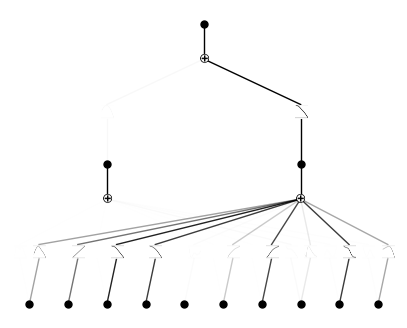

In [118]:
# =====================================================
# 8. Visualizar KAN antes de poda
# =====================================================

print("\nKAN antes de poda")
model.plot()

In [119]:
# =====================================================
# 9. Predicciones del modelo original
# =====================================================

model.eval()

with torch.no_grad():
    pred_train_original_scaled = model(dataset["train_input"])
    pred_test_original_scaled = model(dataset["test_input"])

pred_train_original_scaled = pred_train_original_scaled.detach().cpu().numpy()
pred_test_original_scaled = pred_test_original_scaled.detach().cpu().numpy()

pred_train_original = scaler_y.inverse_transform(
    pred_train_original_scaled
).ravel()

pred_test_original = scaler_y.inverse_transform(
    pred_test_original_scaled
).ravel()

y_train_original = y_train.ravel()
y_test_original = y_test.ravel()

In [120]:
# =====================================================
# 10. Métricas del modelo original
# =====================================================

mse_train_original = mean_squared_error(
    y_train_original,
    pred_train_original
)

rmse_train_original = np.sqrt(mse_train_original)

mae_train_original = mean_absolute_error(
    y_train_original,
    pred_train_original
)

r2_train_original = r2_score(
    y_train_original,
    pred_train_original
)

mse_test_original = mean_squared_error(
    y_test_original,
    pred_test_original
)

rmse_test_original = np.sqrt(mse_test_original)

mae_test_original = mean_absolute_error(
    y_test_original,
    pred_test_original
)

r2_test_original = r2_score(
    y_test_original,
    pred_test_original
)

print("\n" + "=" * 60)
print("KAN original antes de poda")
print("=" * 60)

print(f"Train MSE : {mse_train_original:.4f}")
print(f"Train RMSE: {rmse_train_original:.4f}")
print(f"Train MAE : {mae_train_original:.4f}")
print(f"Train R2  : {r2_train_original:.4f}")

print("-" * 60)

print(f"Test MSE  : {mse_test_original:.4f}")
print(f"Test RMSE : {rmse_test_original:.4f}")
print(f"Test MAE  : {mae_test_original:.4f}")
print(f"Test R2   : {r2_test_original:.4f}")


KAN original antes de poda
Train MSE : 2787.2492
Train RMSE: 52.7944
Train MAE : 42.8410
Train R2  : 0.5467
------------------------------------------------------------
Test MSE  : 2595.5860
Test RMSE : 50.9469
Test MAE  : 40.0550
Test R2   : 0.5192


Cuando el modelo empieza a memorizar el conjunto de entrenamiento y pierde desempeño en prueba, reducimos su complejidad usando menos nodos, una malla más pequeña, más regularización o menos iteraciones. En KAN esto es especialmente importante porque cada conexión aprende una función spline, no solo un peso escalar.

saving model version 0.2

KAN después de poda


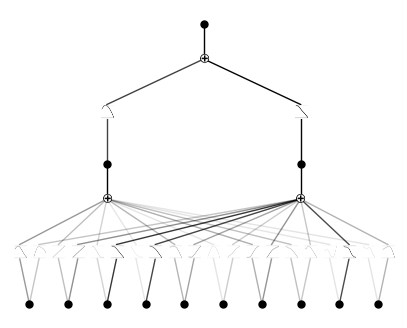

In [101]:
# =====================================================
# 11. Aplicar poda
# =====================================================

model_pruned = model.prune()

print("\nKAN después de poda")
model_pruned.plot()

In [102]:
print("Width original:", model.width_out)
print("Máscaras antes de poda:")

for i, layer in enumerate(model.act_fun):
    print(f"\nLayer {i}")
    print(layer.mask)

print("\n============================\n")
print("Width podado:", model_pruned.width_out)
print("Máscaras después de poda:")

for i, layer in enumerate(model_pruned.act_fun):
    print(f"\nLayer {i}")
    print(layer.mask)

Width original: [10, 2, 1]
Máscaras antes de poda:

Layer 0
Parameter containing:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]], device='cuda:0')

Layer 1
Parameter containing:
tensor([[1.],
        [1.]], device='cuda:0')


Width podado: [10, 2, 1]
Máscaras después de poda:

Layer 0
Parameter containing:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]], device='cuda:0')

Layer 1
Parameter containing:
tensor([[1.],
        [1.]], device='cuda:0')


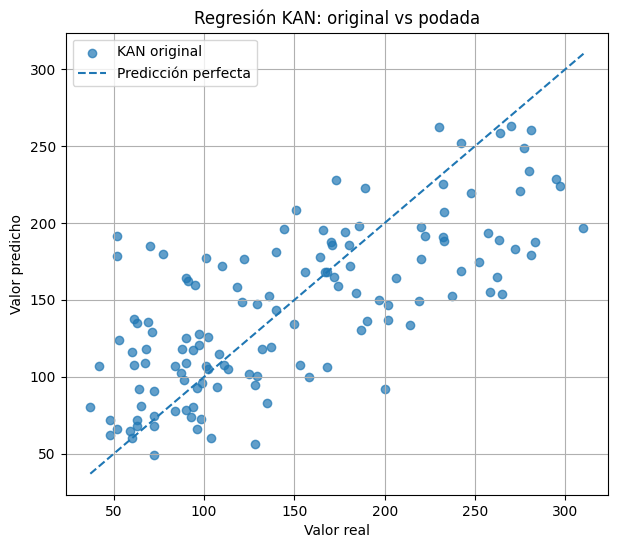

In [121]:
# =====================================================
# 15. Gráfica real vs predicho
# =====================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_original,
    pred_test_original,
    alpha=0.7,
    label="KAN original"
)

min_val = min(
    y_test_original.min(),
    pred_test_original.min(),
)

max_val = max(
    y_test_original.max(),
    pred_test_original.max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión KAN: original vs podada")
plt.legend()
plt.grid(True)
plt.show()

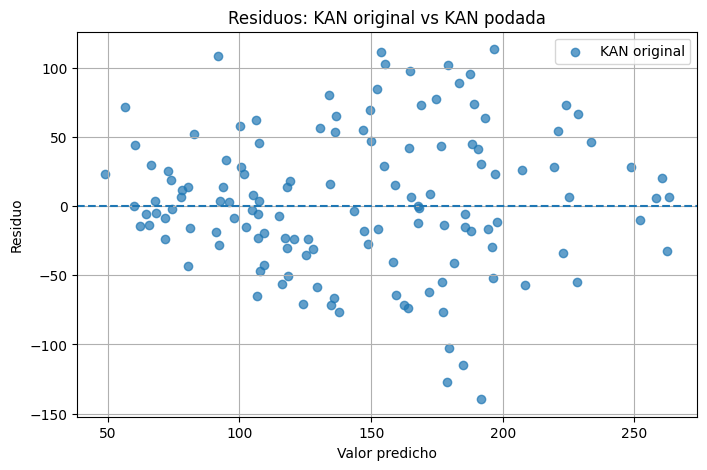

In [123]:
# =====================================================
# 16. Gráfica de residuos
# =====================================================

residuos = y_test_original - pred_test_original

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_test_original,
    residuos,
    alpha=0.7,
    label="KAN original"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Residuos: KAN original vs KAN podada")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
# =====================================================
# 17. Ejemplos de predicciones
# =====================================================

print("\nEjemplos de predicción en test")
print("=" * 90)

for i in range(10):
    print(
        f"Real: {y_test_original[i]:8.2f} | "
        f"Original: {pred_test_original[i]:8.2f} | "
        f"Error original: {y_test_original[i] - pred_test_original[i]:8.2f} | "
    )


Ejemplos de predicción en test
Real:   219.00 | Original:   149.43 | Error original:    69.57 | 
Real:    70.00 | Original:   184.80 | Error original:  -114.80 | 
Real:   202.00 | Original:   136.73 | Error original:    65.27 | 
Real:   230.00 | Original:   262.52 | Error original:   -32.52 | 
Real:   111.00 | Original:   107.39 | Error original:     3.61 | 
Real:    84.00 | Original:    77.80 | Error original:     6.20 | 
Real:   242.00 | Original:   252.24 | Error original:   -10.24 | 
Real:   272.00 | Original:   183.35 | Error original:    88.65 | 
Real:    94.00 | Original:   117.43 | Error original:   -23.43 | 
Real:    96.00 | Original:    92.71 | Error original:     3.29 | 


In [126]:
feature_names = data.feature_names

print("Variables disponibles:")
print(feature_names)

Variables disponibles:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [129]:
# =====================================================
# 4. Seleccionar solo algunas variables
# =====================================================
# Variables disponibles:
# ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
#
# Seleccionaremos:
# bmi -> índice 2
# bp  -> índice 3
# s5  -> índice 8

selected_idx = [2, 3, 8]
selected_features = [feature_names[i] for i in selected_idx]

X_sub = X[:, selected_idx]

print("\nVariables seleccionadas:")
print(selected_features)

print("Forma de X después de seleccionar variables:", X.shape)
print("Forma de X_sub después de seleccionar variables:", X_sub.shape)


Variables seleccionadas:
['bmi', 'bp', 's5']
Forma de X después de seleccionar variables: (442, 10)
Forma de X_sub después de seleccionar variables: (442, 3)


In [130]:
# =====================================================
# 5. División train/test
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_sub,
    y,
    test_size=0.3,
    random_state=42
)

print("\nTamaños:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Tamaños:
X_train: (309, 3)
X_test : (133, 3)
y_train: (309,)
y_test : (133,)


In [131]:
# =====================================================
# 6. Escalamiento de X y y
# =====================================================
# Importante:
# Se ajustan los escaladores SOLO con train.
# Luego se aplican a test.

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [132]:
# =====================================================
# 8. Crear dataset para KAN
# =====================================================

dataset = {}

dataset["train_input"] = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
).to(device)

dataset["test_input"] = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
).to(device)

dataset["train_label"] = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
).to(device)

dataset["test_label"] = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
).to(device)

print("\nTensores para KAN:")
print("train_input:", dataset["train_input"].shape)
print("train_label:", dataset["train_label"].shape)
print("test_input :", dataset["test_input"].shape)
print("test_label :", dataset["test_label"].shape)


Tensores para KAN:
train_input: torch.Size([309, 3])
train_label: torch.Size([309, 1])
test_input : torch.Size([133, 3])
test_label : torch.Size([133, 1])


In [159]:
# =====================================================
# 9. Crear modelo KAN
# =====================================================
# Como usamos 3 variables:
# width=[3, 3, 1]
#
# 3 entradas -> 3 nodos ocultos -> 1 salida
import os
os.makedirs("./checkpoints_diabetes_variables", exist_ok=True)

model = KAN(
    width=[X_train.shape[1], 2, 1],
    grid=3,
    k=3,
    seed=42,
    device=device,
    ckpt_path="./checkpoints_diabetes_variables"
)

checkpoint directory created: ./checkpoints_diabetes_variables
saving model version 0.0


In [160]:
# =====================================================
# 10. Métricas internas para entrenamiento
# =====================================================

def train_mse():
    pred = model(dataset["train_input"])
    return torch.mean((pred - dataset["train_label"]) ** 2)

def test_mse():
    pred = model(dataset["test_input"])
    return torch.mean((pred - dataset["test_label"]) ** 2)

In [161]:
# =====================================================
# 11. Entrenar KAN original
# =====================================================

results = model.fit(
    dataset,
    opt="Adam",
    steps=1000,
    lr=0.001,
    metrics=(train_mse, test_mse),
    loss_fn=torch.nn.MSELoss(),
    lamb=5e-4
)

| train_loss: 7.01e-01 | test_loss: 6.61e-01 | reg: 9.71e+00 | : 100%|█| 1000/1000 [01:14<00:00, 13.


saving model version 0.1



Claves disponibles en results:
dict_keys(['train_loss', 'test_loss', 'reg', 'train_mse', 'test_mse'])


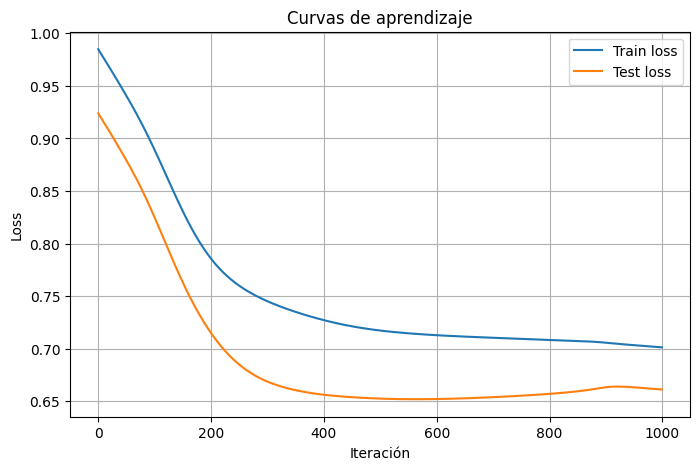

In [162]:
# =====================================================
# 12. Curvas de aprendizaje
# =====================================================

print("\nClaves disponibles en results:")
print(results.keys())

plt.figure(figsize=(8, 5))

if "train_loss" in results:
    plt.plot(results["train_loss"], label="Train loss")

if "test_loss" in results:
    plt.plot(results["test_loss"], label="Test loss")

plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(True)
plt.show()


KAN original antes de poda


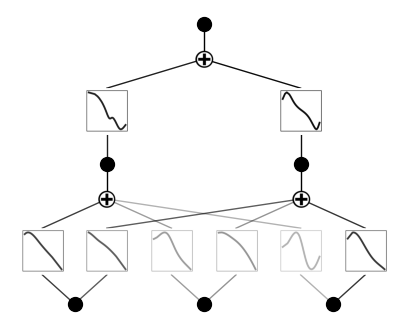

In [163]:
# =====================================================
# 13. Visualizar KAN antes de poda
# =====================================================

print("\nKAN original antes de poda")
model.plot()

In [164]:
# =====================================================
# 14. Predicciones del modelo original
# =====================================================

model.eval()

with torch.no_grad():
    pred_train_original_scaled = model(dataset["train_input"])
    pred_test_original_scaled = model(dataset["test_input"])

pred_train_original_scaled = pred_train_original_scaled.detach().cpu().numpy()
pred_test_original_scaled = pred_test_original_scaled.detach().cpu().numpy()

# Regresar predicciones a escala original
pred_train_original = scaler_y.inverse_transform(
    pred_train_original_scaled
).ravel()

pred_test_original = scaler_y.inverse_transform(
    pred_test_original_scaled
).ravel()

y_train_original = y_train.ravel()
y_test_original = y_test.ravel()

In [165]:
# =====================================================
# 15. Evaluación del modelo original
# =====================================================

mse_train_original = mean_squared_error(
    y_train_original,
    pred_train_original
)

rmse_train_original = np.sqrt(mse_train_original)

mae_train_original = mean_absolute_error(
    y_train_original,
    pred_train_original
)

r2_train_original = r2_score(
    y_train_original,
    pred_train_original
)

mse_test_original = mean_squared_error(
    y_test_original,
    pred_test_original
)

rmse_test_original = np.sqrt(mse_test_original)

mae_test_original = mean_absolute_error(
    y_test_original,
    pred_test_original
)

r2_test_original = r2_score(
    y_test_original,
    pred_test_original
)

print("\n" + "=" * 60)
print("KAN original antes de poda")
print("=" * 60)

print(f"Train MSE : {mse_train_original:.4f}")
print(f"Train RMSE: {rmse_train_original:.4f}")
print(f"Train MAE : {mae_train_original:.4f}")
print(f"Train R2  : {r2_train_original:.4f}")

print("-" * 60)

print(f"Test MSE  : {mse_test_original:.4f}")
print(f"Test RMSE : {rmse_test_original:.4f}")
print(f"Test MAE  : {mae_test_original:.4f}")
print(f"Test R2   : {r2_test_original:.4f}")


KAN original antes de poda
Train MSE : 3022.9383
Train RMSE: 54.9813
Train MAE : 45.2518
Train R2  : 0.5083
------------------------------------------------------------
Test MSE  : 2687.1892
Test RMSE : 51.8381
Test MAE  : 42.1305
Test R2   : 0.5022


saving model version 0.2

KAN después de poda


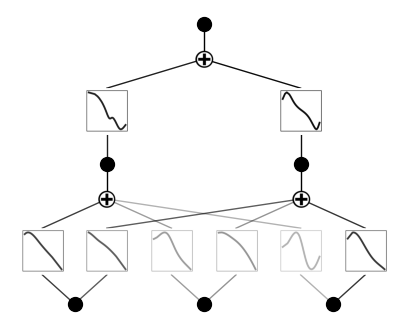

In [166]:
# =====================================================
# 16. Aplicar poda
# =====================================================

model_pruned = model.prune()

print("\nKAN después de poda")
model_pruned.plot()

In [167]:
# =====================================================
# 17. Predicciones del modelo podado
# =====================================================

model_pruned.eval()

with torch.no_grad():
    pred_train_pruned_scaled = model_pruned(dataset["train_input"])
    pred_test_pruned_scaled = model_pruned(dataset["test_input"])

pred_train_pruned_scaled = pred_train_pruned_scaled.detach().cpu().numpy()
pred_test_pruned_scaled = pred_test_pruned_scaled.detach().cpu().numpy()

# Regresar predicciones a escala original
pred_train_pruned = scaler_y.inverse_transform(
    pred_train_pruned_scaled
).ravel()

pred_test_pruned = scaler_y.inverse_transform(
    pred_test_pruned_scaled
).ravel()

In [168]:
# =====================================================
# 18. Evaluación del modelo podado
# =====================================================

mse_train_pruned = mean_squared_error(
    y_train_original,
    pred_train_pruned
)

rmse_train_pruned = np.sqrt(mse_train_pruned)

mae_train_pruned = mean_absolute_error(
    y_train_original,
    pred_train_pruned
)

r2_train_pruned = r2_score(
    y_train_original,
    pred_train_pruned
)

mse_test_pruned = mean_squared_error(
    y_test_original,
    pred_test_pruned
)

rmse_test_pruned = np.sqrt(mse_test_pruned)

mae_test_pruned = mean_absolute_error(
    y_test_original,
    pred_test_pruned
)

r2_test_pruned = r2_score(
    y_test_original,
    pred_test_pruned
)

print("\n" + "=" * 60)
print("KAN podada sin reentrenar")
print("=" * 60)

print(f"Train MSE : {mse_train_pruned:.4f}")
print(f"Train RMSE: {rmse_train_pruned:.4f}")
print(f"Train MAE : {mae_train_pruned:.4f}")
print(f"Train R2  : {r2_train_pruned:.4f}")

print("-" * 60)

print(f"Test MSE  : {mse_test_pruned:.4f}")
print(f"Test RMSE : {rmse_test_pruned:.4f}")
print(f"Test MAE  : {mae_test_pruned:.4f}")
print(f"Test R2   : {r2_test_pruned:.4f}")



KAN podada sin reentrenar
Train MSE : 3022.9383
Train RMSE: 54.9813
Train MAE : 45.2518
Train R2  : 0.5083
------------------------------------------------------------
Test MSE  : 2687.1892
Test RMSE : 51.8381
Test MAE  : 42.1305
Test R2   : 0.5022


In [169]:
# =====================================================
# 19. Comparación original vs podada
# =====================================================

print("\n" + "=" * 90)
print("Comparación: KAN original vs KAN podada")
print("=" * 90)

print(
    f"{'Modelo':<25} "
    f"{'Train RMSE':>12} "
    f"{'Test RMSE':>12} "
    f"{'Train R2':>12} "
    f"{'Test R2':>12}"
)

print("-" * 90)

print(
    f"{'KAN original':<25} "
    f"{rmse_train_original:>12.4f} "
    f"{rmse_test_original:>12.4f} "
    f"{r2_train_original:>12.4f} "
    f"{r2_test_original:>12.4f}"
)

print(
    f"{'KAN podada':<25} "
    f"{rmse_train_pruned:>12.4f} "
    f"{rmse_test_pruned:>12.4f} "
    f"{r2_train_pruned:>12.4f} "
    f"{r2_test_pruned:>12.4f}"
)


Comparación: KAN original vs KAN podada
Modelo                      Train RMSE    Test RMSE     Train R2      Test R2
------------------------------------------------------------------------------------------
KAN original                   54.9813      51.8381       0.5083       0.5022
KAN podada                     54.9813      51.8381       0.5083       0.5022


In [170]:
# =====================================================
# 20. Cambio después de poda
# =====================================================

delta_test_r2 = r2_test_pruned - r2_test_original
delta_test_rmse = rmse_test_pruned - rmse_test_original

print("\nCambio después de poda")
print("=" * 50)
print(f"Delta Test R2   : {delta_test_r2:.4f}")
print(f"Delta Test RMSE : {delta_test_rmse:.4f}")



Cambio después de poda
Delta Test R2   : 0.0000
Delta Test RMSE : -0.0000


In [ ]:
# =====================================================
# 21. Gráfica real vs predicho
# =====================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_original,
    pred_test_original,
    alpha=0.7,
    label="KAN original"
)

plt.scatter(
    y_test_original,
    pred_test_pruned,
    alpha=0.7,
    label="KAN podada"
)

min_val = min(
    y_test_original.min(),
    pred_test_original.min(),
    pred_test_pruned.min()
)

max_val = max(
    y_test_original.max(),
    pred_test_original.max(),
    pred_test_pruned.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión KAN: original vs podada")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =====================================================
# 22. Gráfica de residuos
# =====================================================

residuos_original = y_test_original - pred_test_original
residuos_pruned = y_test_original - pred_test_pruned

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_test_original,
    residuos_original,
    alpha=0.7,
    label="KAN original"
)

plt.scatter(
    pred_test_pruned,
    residuos_pruned,
    alpha=0.7,
    label="KAN podada"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Residuos: KAN original vs KAN podada")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =====================================================
# 23. Ejemplos de predicciones
# =====================================================

print("\nEjemplos de predicción en test")
print("=" * 90)

for i in range(10):
    print(
        f"Real: {y_test_original[i]:8.2f} | "
        f"Original: {pred_test_original[i]:8.2f} | "
        f"Podada: {pred_test_pruned[i]:8.2f} | "
        f"Error original: {y_test_original[i] - pred_test_original[i]:8.2f} | "
        f"Error podada: {y_test_original[i] - pred_test_pruned[i]:8.2f}"
    )